In [15]:
import os
import sys

project_root = os.path.abspath("../..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

d:\Data Analyst Agent


In [16]:
from langgraph.graph import StateGraph, START, END
from backend.graphs.state import DataAnalystState

from backend.agents.dataset_agent import dataset_agent
from backend.agents.eda_agent import EDAAgent
from backend.agents.insight_agent import InsightAgent
from backend.agents.planner_agent import PlannerAgent
from backend.agents.reflection_agent import ReflectionAgent
from backend.agents.report_agent import ReportAgent
from backend.agents.reviewer_agent import ReviewerAgent
from backend.agents.visualization_agent import VisualizationAgent

In [17]:
eda_agent = EDAAgent()
planner_agent = PlannerAgent()
visualization_agent = VisualizationAgent()
insight_agent = InsightAgent()
reviewer_agent = ReviewerAgent()
reflection_agent = ReflectionAgent()
report_agent = ReportAgent()

In [18]:
def dataset_node(state):
    return dataset_agent.run(state)

def eda_node(state):
    return eda_agent.run(state)

def planner_node(state):
    return planner_agent.run(state)

def visualization_node(state):
    return visualization_agent.run(state)

def insight_node(state):
    return insight_agent.run(state)

def reviewer_node(state):
    return reviewer_agent.run(state)

def reflection_node(state):
    return reflection_agent.run(state)

def report_node(state):
    return report_agent.run(state)

In [19]:
graph = StateGraph(DataAnalystState)

graph.add_node("dataset", dataset_node)
graph.add_node("planner", planner_node)
graph.add_node("eda", eda_node)
graph.add_node("visualization", visualization_node)
graph.add_node("insight", insight_node)
graph.add_node("review", reviewer_node)
graph.add_node("reflection", reflection_node)
graph.add_node("report", report_node)

In [20]:
graph.add_edge(START, "dataset")
graph.add_edge("dataset", "planner")
graph.add_edge("planner", "eda")
graph.add_edge("eda", "visualization")
graph.add_edge("visualization", "insight")
graph.add_edge("insight", "review")

In [21]:
def review_router(state):
    if state["review_passed"] == "passed":
        return "report"
    return "reflection"

In [22]:
graph.add_conditional_edges(
    "review",
    review_router,
    {
        "report": "report",
        "reflection": "reflection",
    }
)

In [23]:
graph.add_edge("reflection", "planner")
graph.add_edge("report", END)

In [24]:
complete = graph.compile()

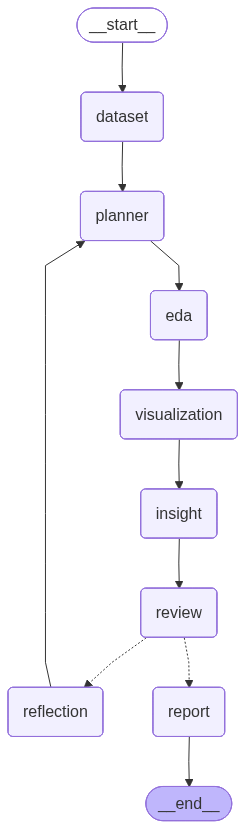

In [25]:
complete

In [26]:
initial_state = {

    "file_path":"D:\\Data Analyst Agent\\datasets\\SampleSuperstore.csv"

}

In [27]:
result = complete.invoke(initial_state)

AttributeError: 'function' object has no attribute 'run'